In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pickle
from sentence_transformers import SentenceTransformer
import re
import torch
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:

df = pd.read_excel("all thesis.xlsx", sheet_name="thesis")

In [18]:
# Display the columis names of the DataFrame
df.columns

Index(['ID', 'Title', 'Category', 'GroupName', 'class', 'Year'], dtype='object')

In [19]:
# Display the shape  of the DataFrame
df.shape

(333, 6)

In [20]:
df.head()

,ID,Title,Category,GroupName,class,Year
0,TH001,Virtual Private Network for Local Bank Branches,Educational Sciences,Unknown,CA121,2012.0
1,TH002,Public District Registration System,Educational Sciences,Unknown,CA121,2012.0
2,TH003,Driving License Management,Educational Sciences,Unknown,CA121,2012.0
3,TH004,School Management System,Educational Sciences,Unknown,CA121,2012.0
4,TH005,Car Rental Management,Educational Sciences,Unknown,CA121,2012.0


In [21]:
# Display the concise summary  of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         326 non-null    object 
 1   Title      326 non-null    object 
 2   Category   291 non-null    object 
 3   GroupName  293 non-null    object 
 4   class      190 non-null    object 
 5   Year       325 non-null    float64
dtypes: float64(1), object(5)
memory usage: 15.7+ KB


In [22]:
df.describe()  # Tirakoobyo guud

,Year
count,325.000000
mean,2016.883077
std,2.283568
min,2012.000000
25%,2015.000000
50%,2018.000000
75%,2019.000000
max,2019.000000


In [7]:
df.columns     # Magacyada columns-ka

Index(['ID', 'Title', 'Category', 'GroupName', 'class', 'Year'], dtype='object')

In [29]:
df = df.drop(columns=['GroupName', 'class'])

In [23]:
# Checking for missing values
df.isnull().sum()


,0
ID,7
Title,7
Category,42
GroupName,40
class,143
Year,8


In [11]:
# filling missing values
df = df.dropna

In [24]:
# Identifying Rows with Missing Values
df[df.isnull().any(axis=1)]

,ID,Title,Category,GroupName,class,Year
23,NaN,NaN,NaN,NaN,NaN,NaN
45,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN
87,NaN,NaN,NaN,NaN,NaN,NaN
112,TH104,Implementation of digital Notice board Using R...,NaN,Group 10 Pt,CA165,2016.0
...,...,...,...,...,...,...
328,TH317,UNDERGROUND CABLE FAULT DETECTION USING ARDUIN...,IOT,Group 102,NaN,2019.0
329,TH318,Design and implementation of a Systematic port...,web development,Group 103,NaN,2019.0
330,TH319,iot prison break monitoring and alerting system,IOT,Group 104,NaN,2019.0
331,TH320,REDUCING IDLE STREETLIGHTS ENERGY CONSUMPTION ...,IOT,Group 105,NaN,2019.0


In [25]:
df[df['Title'].isnull()]


,ID,Title,Category,GroupName,class,Year
23,NaN,NaN,NaN,NaN,NaN,NaN
45,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN
87,NaN,NaN,NaN,NaN,NaN,NaN
113,NaN,NaN,NaN,NaN,NaN,NaN
146,NaN,NaN,NaN,NaN,NaN,NaN
229,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df = df.dropna(subset=['Title', 'Year', 'ID'])


In [27]:
df["Category"] = df["Category"].fillna("Unknown")

In [30]:
df.isnull().sum()


,0
ID,0
Title,0
Category,0
Year,0


In [15]:
df['Year'].unique()


array([2012., 2013., 2014., 2015., 2016., 2017., 2018., 2019.])

In [16]:
df['Year'] = df['Year'].astype(int)


In [17]:
df['Year'].unique()


array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])

In [18]:
df["Category"].unique()

array(['Educational Sciences', 'Science and technology',
       'Communication science', 'Web Developement',
       'Art and architecture', 'Internet of Things',
       'Artificial Intelligence', 'Network ', 'Unknown',
       'mobile application', 'machine learning', 'IOT',
       'Mobile Application', 'Web development', 'Blockchain',
       'Machine Learning', 'Image processing', 'NLP', 'Networking',
       'Web Development', 'web development', 'Image recognition',
       'Web Development (php)', 'Web & Mobile app', 'Web ( with opencv)',
       'opencv', 'deep learning'], dtype=object)

In [19]:
replace_dict = {
    # Web-related
    "web development": "Web",
    "web developement": "Web",
    "web development (php)": "Web",
    "web & mobile app": "Web",
    "web ( with opencv)": "Web",
    "web": "Web",
    "web apps": "Web",

    # Mobile-related
    "mobile application": "Mobile",
    "mobile app": "Mobile",
    "mobile": "Mobile",

    # AI & ML
    "artificial intelligence": "AI",
    "machine learning": "AI",
    "deep learning": "AI",
    "nlp": "AI",
    "image recognition": "AI",
    "image processing": "AI",
    "opencv": "AI",

    # IoT
    "iot": "IoT",
    "internet of things": "IoT",

    # Networking
    "network": "Networking",
    "network ": "Networking",
    "networking": "Networking",

    # Blockchain
    "blockchain": "Blockchain",

    # Education / Science
    "educational sciences": "Education",
    "science and technology": "Science",
    "communication science": "Science",
    "art and architecture": "Design",

    # Unknown
    "unknown": "Unknown"
}


In [20]:
# Lowercase & strip spaces
df["Category"] = df["Category"].str.lower().str.strip()

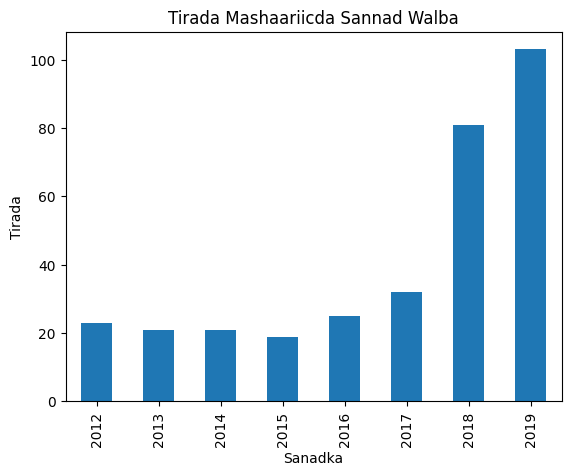

In [21]:
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title("Tirada Mashaariicda Sannad Walba")
plt.xlabel("Sanadka")
plt.ylabel("Tirada")
plt.show()

<Figure size 1200x600 with 0 Axes>

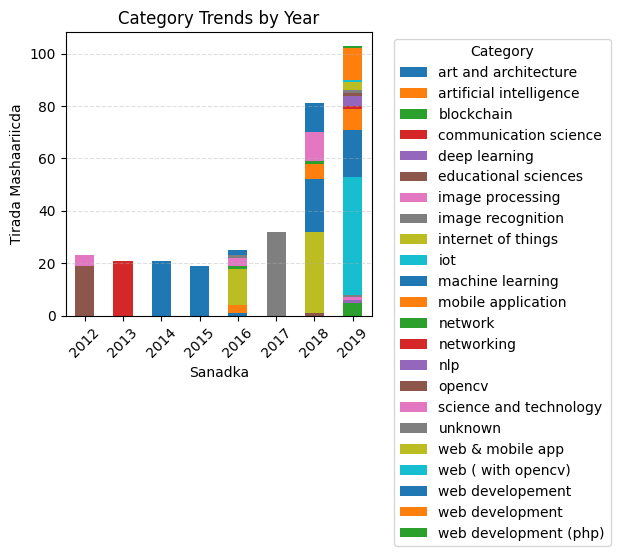

In [22]:
# ======= 7. Trend-ka Category-ga Sannad Walba (Stacked Bar Chart) =======
trend = df.groupby(['Year', 'Category']).size().unstack().fillna(0)

plt.figure(figsize=(12,6))
trend.plot(kind='bar', stacked=True)
plt.title("Category Trends by Year")
plt.xlabel("Sanadka")
plt.ylabel("Tirada Mashaariicda")
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [31]:
# Group by Year and Category, count tirada mashruucyada
category_counts = df.groupby(['Year', 'Category']).size().reset_index(name='Count')

# Sort si uu u helo category-ga ugu tirada badan sanad walba
most_common_per_year = category_counts.sort_values('Count', ascending=False).drop_duplicates('Year')

# Dib u habee (optional) – si sanad ahaan loo kala hormariyo
most_common_per_year = most_common_per_year.sort_values('Year')

# Daabac natiijada
print("Sanad walba category-ga ugu badan:")
print(most_common_per_year)


Sanad walba category-ga ugu badan:
      Year               Category  Count
0   2012.0   Educational Sciences     19
2   2013.0  Communication science     21
3   2014.0       Web Developement     21
4   2015.0       Web Developement     19
7   2016.0     Internet of Things     14
12  2017.0                Unknown     32
14  2018.0     Internet of Things     31
21  2019.0                    IOT     45


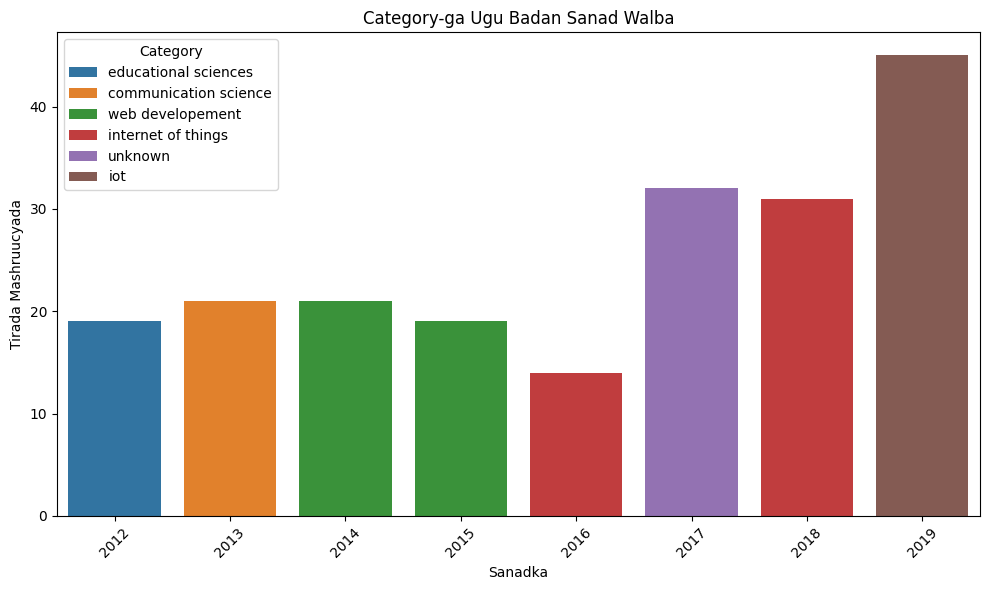

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=most_common_per_year, x='Year', y='Count', hue='Category')
plt.title("Category-ga Ugu Badan Sanad Walba")
plt.ylabel("Tirada Mashruucyada")
plt.xlabel("Sanadka")
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()


Sanadaha uu ku jiro category-ga: [2014 2015 2016 2018]
Tirada mashruucyo: 53


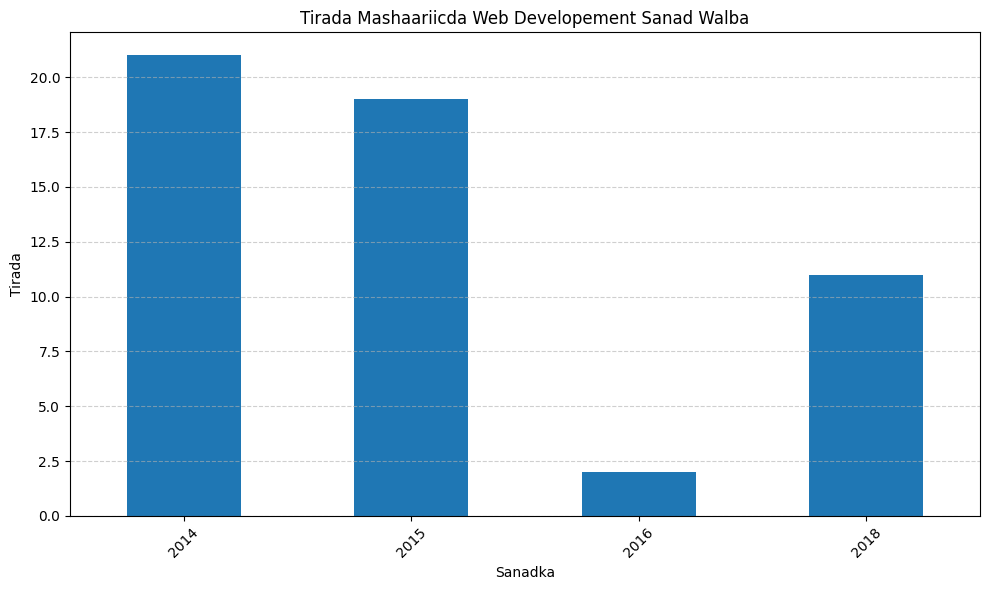

In [25]:
# ✅ 1. Nadiifi column-ka Category (firaaqooyin & xarfo waaweyn/yaryar)
df['Category'] = df['Category'].astype(str).str.strip()

# ✅ 2. Dooro category-ga aad rabto
category_lagu_fiirinayo = "Web Developement"  # Bedel haddii loo baahdo

# ✅ 3. Filter garee xogta iyadoo la eegayo category-ga si nadiif ah
filtered = df[df['Category'].str.lower() == category_lagu_fiirinayo.lower()]

# ✅ 4. Tiri sanad walba
tirada_sanad_walba = filtered['Year'].value_counts().sort_index()

# ✅ 5. Save to Excel (optional)
tirada_sanad_walba.to_excel("category_ai_sanad_walba.xlsx")
print("Sanadaha uu ku jiro category-ga:", filtered['Year'].unique())
print("Tirada mashruucyo:", len(filtered))


# ✅ 6. Sawir chart
plt.figure(figsize=(10,6))
tirada_sanad_walba.plot(kind='bar')
plt.title(f"Tirada Mashaariicda {category_lagu_fiirinayo} Sanad Walba")
plt.xlabel("Sanadka")
plt.ylabel("Tirada")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


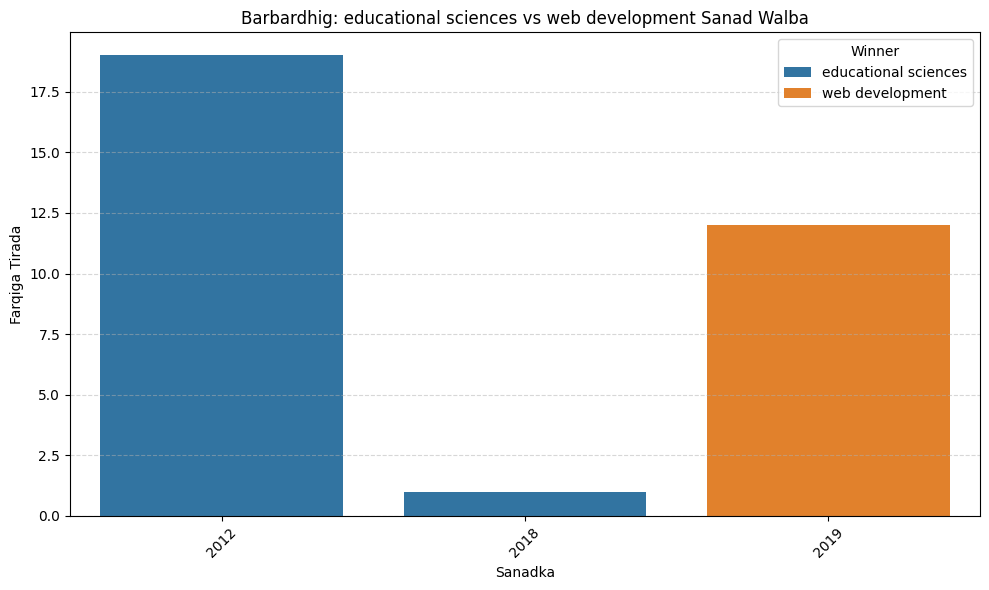

In [27]:
# ✅ 1. Nadiifi Category (strip & lower optional)
df['Category'] = df['Category'].astype(str).str.strip()

# ✅ 2. Dooro labada category ee la is barbar dhigayaa
cat1 = "educational sciences"
cat2 = "web development"

# ✅ 3. Filter garee labada category
filtered_df = df[df['Category'].str.lower().isin([cat1.lower(), cat2.lower()])]

# ✅ 4. Tiri sanad walba category kasta
category_counts = filtered_df.groupby(['Year', 'Category']).size().reset_index(name='Count')

# ✅ 5. U beddel format la is barbar dhigi karo
pivot = category_counts.pivot(index='Year', columns='Category', values='Count').fillna(0)


# ✅ 6. Samee column cusub: midka ku guuleystay sanad walba
pivot['Winner'] = pivot[[cat1, cat2]].idxmax(axis=1)
pivot['Difference'] = pivot[[cat1, cat2]].max(axis=1) - pivot[[cat1, cat2]].min(axis=1)

# ✅ 8. Optional: Sawir guuleystayaasha sanad walba
plt.figure(figsize=(10,6))
sns.barplot(x=pivot.index, y=pivot['Difference'], hue=pivot['Winner'])
plt.title(f"Barbardhig: {cat1} vs {cat2} Sanad Walba")
plt.xlabel("Sanadka")
plt.ylabel("Farqiga Tirada")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
df.head()

,ID,Title,Category,Year
0,TH001,Virtual Private Network for Local Bank Branches,educational sciences,2012
1,TH002,Public District Registration System,educational sciences,2012
2,TH003,Driving License Management,educational sciences,2012
3,TH004,School Management System,educational sciences,2012
4,TH005,Car Rental Management,educational sciences,2012


In [29]:
from sentence_transformers import SentenceTransformer
import pandas as pd

# Model SBERT
model = SentenceTransformer('all-MiniLM-L6-v2')

# Tusaale: Clean title (si fudud lowercase)
df['cleaned_title'] = df['Title'].astype(str).str.strip().str.lower()

# Samee vector (SBERT embedding)
vectors = model.encode(df['cleaned_title'].tolist(), show_progress_bar=True)

# Ku dar column cusub: vector as string si uu CSV u aqbalo
df['vector'] = [vec.tolist() for vec in vectors]


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [30]:
df.head()

,ID,Title,Category,Year,cleaned_title,vector
0,TH001,Virtual Private Network for Local Bank Branches,educational sciences,2012,virtual private network for local bank branches,"[0.08137169480323792, -0.01046018861234188, -0..."
1,TH002,Public District Registration System,educational sciences,2012,public district registration system,"[-0.006014076992869377, -0.05311119183897972, ..."
2,TH003,Driving License Management,educational sciences,2012,driving license management,"[0.034380730241537094, -0.014175023883581161, ..."
3,TH004,School Management System,educational sciences,2012,school management system,"[-0.0493132658302784, 0.06124800816178322, -0...."
4,TH005,Car Rental Management,educational sciences,2012,car rental management,"[0.023545293137431145, 0.025300564244389534, -..."


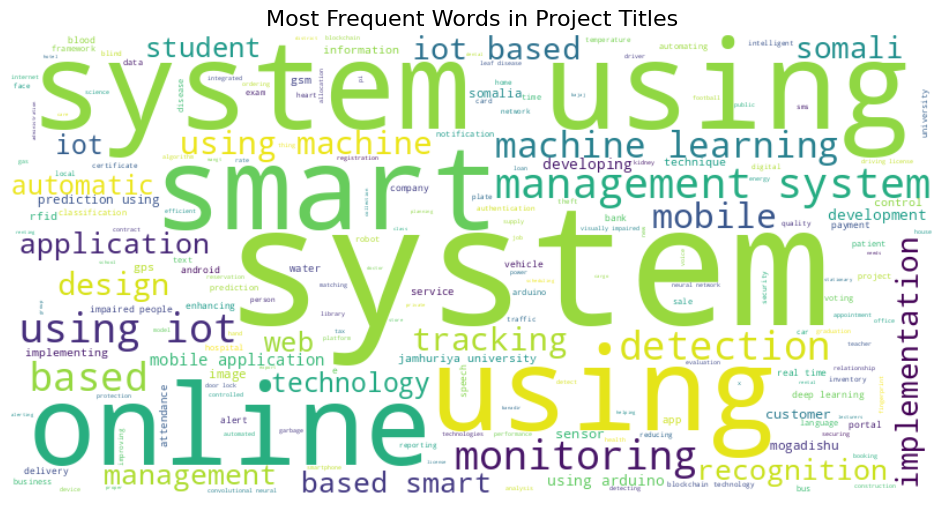

In [35]:
text = ' '.join(df['cleaned_title'])  # Column cleaned_title ama mid aad nadiifisay

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Project Titles", fontsize=16)
plt.show()


In [31]:
# Save to file
output_path = "/content/cleaned_projects.csv"
df.to_csv(output_path, index=False)

# Show download link in Colab
from google.colab import files
files.download(output_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>